# **Day 90: Project 1 - Land Use / Land Cover Mapping (Part 2): Model Comparison under Spatial Cross-Validation**
*Module 13 - Remote Sensing ML and Publication Projects*

Today answers **RQ1** (which classifier?) and **RQ2** (which data sources matter?) with the rigour reviewers expect:
- every model is **tuned inside** the cross-validation (nested CV), so the reported score never saw its own tuning data
- all folds are **spatial blocks** (Day 88)
- differences are tested for **significance**, and multiple comparisons are corrected
- the contribution of each data source is measured by an **ablation study** with repeated spatial CV
- the final model is tuned on all data and **saved with its metadata**

> Here we compare several classifiers fairly: the same data, the same spatial folds and the same tuning budget, with statistical tests to see whether differences are real. An ablation study shows which data sources actually help.
>
> *Example:* If adding Sentinel-1 radar raises accuracy from 0.86 to 0.89 and the test says the gain is significant, radar earns its place in the method.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, time, sys, joblib, hashlib, platform, warnings
from pathlib import Path
from scipy import stats
from scipy.stats import loguniform
import sklearn, xgboost as xgb, lightgbm as lgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GroupKFold, KFold, RandomizedSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests
import rs_utils as ru
ru.pub_style()
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
warnings.filterwarnings("ignore", message="The total space of parameters")      # small RF grid: RandomizedSearchCV simply runs all of it

PROJ = Path("project1_lulc")
config = json.loads((PROJ / "config.json").read_text()); SEED = config["seed"]
train = pd.read_csv(PROJ / "data/training_table.csv")
finfo = json.loads((PROJ / "data/feature_list.json").read_text())
feats = finfo["reduced"]
X, y, groups = train[feats].values, train["class_id"].values, train["block"].values
print(f"{len(y)} samples, {len(feats)} features (reduced set), {len(np.unique(groups))} spatial blocks of {config['cv']['block_size_m']} m")

598 samples, 68 features (reduced set), 25 spatial blocks of 2000 m


## **1. A Fair Comparison**
| Choice | Our setting | Why |
|---|---|---|
| Folds | the same 5 spatial-block folds for every model | paired comparison |
| Tuning | `RandomizedSearchCV`, 6 candidates, inner 3-fold **spatial** CV | equal budget; no leakage |
| Metric for tuning and ranking | macro F1 | all classes count equally (the training sample is class-stratified) |
| Preprocessing | scaling inside a `Pipeline` | fitted on training folds only |

A note on what these numbers mean: because the reference sample is stratified by **class**, CV accuracy is not the accuracy of the **map** (which is area-weighted). The map accuracy comes from the independent probability sample in Day 91.

In [2]:
models = {
    "LR": (make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
           {"logisticregression__C": loguniform(1e-2, 1e2)}),
    "RF": (RandomForestClassifier(300, n_jobs=-1, random_state=SEED),
           {"max_features": ["sqrt", 0.2, 0.4], "min_samples_leaf": [1, 2, 5]}),
    "SVM": (make_pipeline(StandardScaler(), SVC()),
            {"svc__C": loguniform(1e-1, 1e3), "svc__gamma": loguniform(1e-4, 1e-1)}),
    "XGBoost": (xgb.XGBClassifier(n_estimators=200, learning_rate=0.08, tree_method="hist", n_jobs=4, random_state=SEED),
                {"max_depth": [3, 5, 7], "subsample": [0.7, 1.0], "colsample_bytree": [0.5, 0.8], "min_child_weight": [1, 3]}),
    "LightGBM": (lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=SEED, n_jobs=4),
                 {"num_leaves": [7, 15, 31], "min_child_samples": [5, 10, 20], "colsample_bytree": [0.5, 0.8]}),
    "MLP": (make_pipeline(StandardScaler(), MLPClassifier((64, 32), max_iter=600, early_stopping=True, random_state=SEED)),
            {"mlpclassifier__alpha": loguniform(1e-5, 1e-1), "mlpclassifier__learning_rate_init": loguniform(1e-4, 1e-2)}),
}
outer = list(GroupKFold(config["cv"]["n_folds"]).split(X, y, groups))

def mf1(y_true, y_pred):
    """Macro F1 over the classes present in this test fold. A spatial fold may contain no water at all; scoring the absent
    class as F1 = 0 (sklearn's default when it is predicted) would distort fold-level averages."""
    return f1_score(y_true, y_pred, average="macro", labels=np.unique(y_true))
from sklearn.metrics import make_scorer
mf1_scorer = make_scorer(mf1)
print("test-fold sizes:", [len(te) for _, te in outer])

test-fold sizes: [116, 122, 122, 116, 122]


## **2. Nested Spatial Cross-Validation**
Outer loop: estimate performance. Inner loop: choose hyperparameters using only the outer-training data. The selected hyperparameters may differ between folds. That is expected: we evaluate the *procedure* "tune, then fit".

In [3]:
def nested_spatial_cv(est, space, X, y, groups, n_iter=6, seed=SEED):
    oof = np.empty(len(y), int); rows = []
    for k, (tr, te) in enumerate(outer):
        search = RandomizedSearchCV(est, space, n_iter=n_iter, cv=GroupKFold(3), scoring=mf1_scorer, random_state=seed, n_jobs=1)
        search.fit(X[tr], y[tr], groups=groups[tr])
        oof[te] = search.predict(X[te])
        rows.append({"fold": k, "OA": accuracy_score(y[te], oof[te]), "macro_F1": mf1(y[te], oof[te]),
                     "params": search.best_params_})
    return oof, pd.DataFrame(rows)

results, oofs = {}, {}
for name, (est, space) in models.items():
    t0 = time.perf_counter()
    oofs[name], results[name] = nested_spatial_cv(est, space, X, y, groups)
    print(f"{name:<9} pooled macro F1 {f1_score(y, oofs[name], average='macro'):.3f} | fold OA {results[name].OA.mean():.3f} +/- {results[name].OA.std():.3f}  ({time.perf_counter() - t0:.0f} s)")

LR        pooled macro F1 0.865 | fold OA 0.865 +/- 0.039  (2 s)


RF        pooled macro F1 0.907 | fold OA 0.906 +/- 0.014  (31 s)


SVM       pooled macro F1 0.865 | fold OA 0.866 +/- 0.046  (1 s)


XGBoost   pooled macro F1 0.919 | fold OA 0.918 +/- 0.013  (43 s)


LightGBM  pooled macro F1 0.917 | fold OA 0.916 +/- 0.027  (24 s)


MLP       pooled macro F1 0.858 | fold OA 0.859 +/- 0.079  (4 s)


## **3. Table 2: Model Comparison**
**Which summary of the folds?** Spatial folds are strongly class-imbalanced: a 2 km block grid can leave one test fold with a single mining sample, and that class then scores F1 = 0 or 1 by chance. Averaging macro F1 over folds is therefore noisy and biased low. The robust summary is macro F1 computed on the **pooled out-of-fold predictions** (every sample predicted exactly once, by a model that never saw its block), with a **bootstrap 95% CI**. Overall accuracy, which is stable per fold, is reported as mean +/- s.d. over folds.

In [4]:
per_class = {n: f1_score(y, o, average=None) for n, o in oofs.items()}
def boot_ci(y_true, y_pred, B=1000, seed=0):
    r = np.random.default_rng(seed); n = len(y_true)
    vals = [f1_score(y_true[i], y_pred[i], average="macro") for i in (r.integers(0, n, n) for _ in range(B))]
    return np.percentile(vals, [2.5, 97.5])
cis = {n: boot_ci(y, o) for n, o in oofs.items()}
table2 = pd.DataFrame({n: {"OA (mean)": r.OA.mean(), "OA (s.d.)": r.OA.std(), "macro F1": f1_score(y, oofs[n], average="macro"),
                           "macro F1 CI low": cis[n][0], "macro F1 CI high": cis[n][1],
                           **{f"F1 {c}": per_class[n][k] for k, c in enumerate(ru.LC_CLASSES)}} for n, r in results.items()}).T
table2 = table2.sort_values("macro F1", ascending=False)
table2.round(3).to_csv(PROJ / "outputs/tables/table2_model_comparison.csv")
best = table2.index[0]
print("best model by pooled out-of-fold macro F1:", best)
table2.round(3)

best model by pooled out-of-fold macro F1: XGBoost


,OA (mean),OA (s.d.),macro F1,macro F1 CI low,macro F1 CI high,F1 water,F1 forest,F1 cropland,F1 built_up,F1 mining_bare,F1 shrub_grass
XGBoost,0.918,0.013,0.919,0.893,0.938,0.948,0.949,0.880,0.935,0.970,0.829
LightGBM,0.916,0.027,0.917,0.893,0.939,0.932,0.949,0.884,0.929,0.965,0.842
RF,0.906,0.014,0.907,0.882,0.929,0.930,0.925,0.871,0.929,0.956,0.831
SVM,0.866,0.046,0.865,0.837,0.891,0.892,0.898,0.846,0.912,0.911,0.733
LR,0.865,0.039,0.865,0.836,0.890,0.899,0.910,0.866,0.877,0.849,0.786
MLP,0.859,0.079,0.858,0.828,0.885,0.944,0.913,0.788,0.893,0.934,0.674


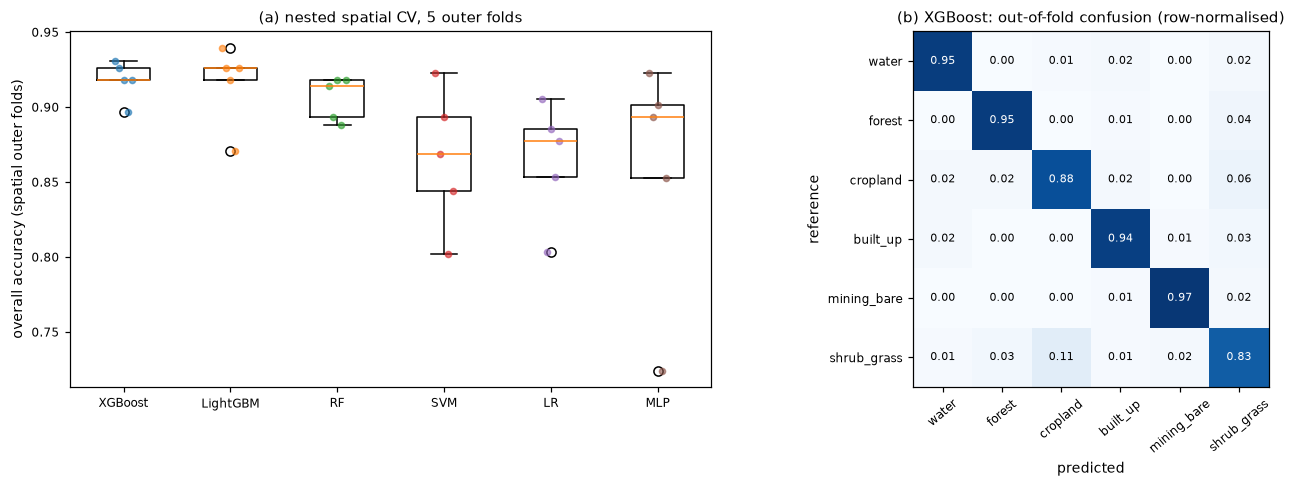

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = list(table2.index)
axes[0].boxplot([results[n].OA for n in order], tick_labels=order)
for i, n in enumerate(order): axes[0].plot(np.full(5, i + 1) + np.linspace(-0.08, 0.08, 5), results[n].OA, "o", ms=4, alpha=0.6)
axes[0].set_ylabel("overall accuracy (spatial outer folds)"); axes[0].set_title("(a) nested spatial CV, 5 outer folds")
cm = confusion_matrix(y, oofs[best], normalize="true")
im = axes[1].imshow(cm, cmap="Blues", vmin=0, vmax=1)
for i in range(6):
    for j in range(6): axes[1].text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7, color="w" if cm[i, j] > 0.6 else "k")
axes[1].set_xticks(range(6), ru.LC_CLASSES, rotation=40); axes[1].set_yticks(range(6), ru.LC_CLASSES)
axes[1].set_xlabel("predicted"); axes[1].set_ylabel("reference"); axes[1].set_title(f"(b) {best}: out-of-fold confusion (row-normalised)")
plt.tight_layout(); fig.savefig(PROJ / "outputs/figures/fig4_model_comparison.png", dpi=300, bbox_inches="tight"); plt.show()

## **4. Are the Differences Significant?**
**McNemar's test** compares two classifiers on the **same** test samples using only the samples where they disagree (b = A right, B wrong; c = A wrong, B right). With five comparisons against the best model we control the family-wise error with **Holm's** correction.

Caveat: McNemar treats samples as independent. Spatially autocorrelated samples make it somewhat liberal (p-values too small). Report it together with the fold-level spread, not instead of it.

In [6]:
rows = []
for n in order[1:]:
    a_ok, b_ok = oofs[best] == y, oofs[n] == y
    tab = [[np.sum(a_ok & b_ok), np.sum(a_ok & ~b_ok)], [np.sum(~a_ok & b_ok), np.sum(~a_ok & ~b_ok)]]
    res = mcnemar(tab, exact=False, correction=True)
    rows.append({"comparison": f"{best} vs {n}", "best right / other wrong": tab[0][1], "best wrong / other right": tab[1][0], "p (raw)": res.pvalue})
mc = pd.DataFrame(rows)
mc["p (Holm)"] = multipletests(mc["p (raw)"], method="holm")[1]
mc["significant at 0.05"] = mc["p (Holm)"] < 0.05
mc.round(4)

,comparison,best right / other wrong,best wrong / other right,p (raw),p (Holm),significant at 0.05
0,XGBoost vs LightGBM,6,5,1.0000,1.0000,False
1,XGBoost vs RF,14,7,0.1904,0.3809,False
2,XGBoost vs SVM,37,6,0.0000,0.0000,True
3,XGBoost vs LR,41,9,0.0000,0.0000,True
4,XGBoost vs MLP,47,12,0.0000,0.0000,True


## **5. Table 3: Which Data Sources Matter? (Ablation)**
We add feature groups one at a time, from the single-date Sentinel-2 baseline up to the full set. Five folds give a noisy estimate, so we use **repeated** spatial CV (3 repeats x 5 folds, with blocks randomly reassigned to folds). We compare each step with the full model using the **corrected resampled t-test** (Nadeau & Bengio 2003), which inflates the variance to account for overlapping training sets (Day 42). For each feature set we report the pooled out-of-fold macro F1 (averaged over the 3 repeats) and the fold-level overall accuracy. The paired test uses the 15 fold-level accuracies, which, unlike per-fold macro F1, stay stable when a fold happens to contain few samples of a class.

To keep the cost low and the comparison clean, the ablation uses one model (RF with fixed default settings) and all features in each group.

In [7]:
groups_of = finfo["groups"]
steps = [("S2 monsoon (baseline)", ["S2_monsoon"]), ("+ S2 other seasons", ["S2_multiseason"]), ("+ indices & temporal", ["S2_index", "temporal"]),
         ("+ Sentinel-1", ["S1"]), ("+ texture", ["texture"]), ("+ terrain (all)", ["terrain"])]
REPEATS = 3
splits = [(r, list(GroupKFold(5, shuffle=True, random_state=r).split(X, y, groups))) for r in range(REPEATS)]

def repeated_scores(cols, model_fn):
    """Per-fold overall accuracy (stable per fold, used for the paired test) and pooled out-of-fold macro F1 (mean over repeats)."""
    Xs = train[cols].values; oa, f1s = [], []
    for r, folds in splits:
        oof = np.empty(len(y), int)
        for tr, te in folds:
            oof[te] = model_fn().fit(Xs[tr], y[tr]).predict(Xs[te]); oa.append(accuracy_score(y[te], oof[te]))
        f1s.append(f1_score(y, oof, average="macro"))
    return np.array(oa), float(np.mean(f1s))

def corrected_ttest(a, b, n_train, n_test):
    d = a - b; k = len(d)
    var = (1 / k + n_test / n_train) * d.var(ddof=1)
    t = d.mean() / np.sqrt(var); return t, 2 * stats.t.sf(abs(t), k - 1)

rf_fixed = lambda: RandomForestClassifier(300, n_jobs=-1, random_state=SEED)
used, ablation = [], {}
for label, gs in steps:
    used += [f for f in finfo["all"] if groups_of[f] in gs]
    ablation[label] = (len(used), *repeated_scores(list(used), rf_fixed))
full = ablation[steps[-1][0]][1]
n_te = len(y) / 5; n_tr = len(y) - n_te
table3 = pd.DataFrame([{"feature set": k, "n features": nf, "macro F1 (pooled)": f1p, "OA (mean)": s.mean(), "OA (s.d.)": s.std(),
                        "OA diff vs full": s.mean() - full.mean(), "p vs full (corrected t)": corrected_ttest(s, full, n_tr, n_te)[1] if k != steps[-1][0] else np.nan}
                       for k, (nf, s, f1p) in ablation.items()])
table3.round(4).to_csv(PROJ / "outputs/tables/table3_ablation.csv", index=False)
table3.round(4)

,feature set,n features,macro F1 (pooled),OA (mean),OA (s.d.),OA diff vs full,p vs full (corrected t)
0,S2 monsoon (baseline),10,0.7908,0.7861,0.0477,-0.1227,0.0000
1,+ S2 other seasons,40,0.8622,0.8592,0.0445,-0.0496,0.0046
2,+ indices & temporal,66,0.8731,0.8704,0.0421,-0.0385,0.0088
3,+ Sentinel-1,72,0.9074,0.9053,0.0376,-0.0036,0.6810
4,+ texture,77,0.9011,0.8989,0.0363,-0.0100,0.1927
5,+ terrain (all),81,0.9105,0.9089,0.0314,0.0000,NaN


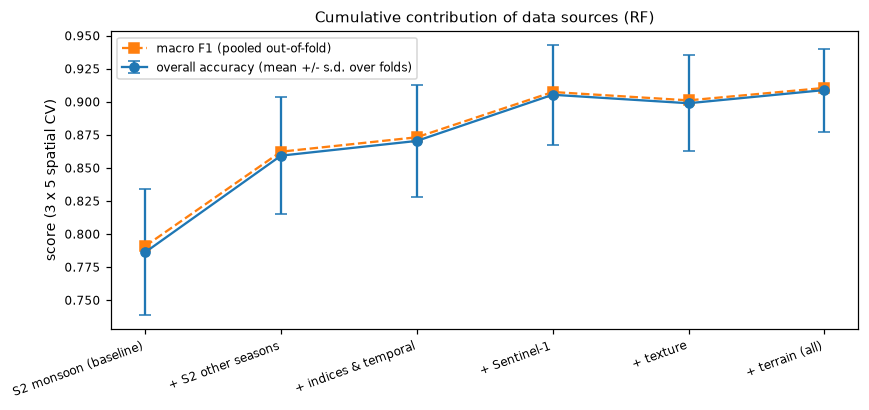

In [8]:
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.errorbar(range(len(table3)), table3["OA (mean)"], yerr=table3["OA (s.d.)"], fmt="-o", capsize=4, label="overall accuracy (mean +/- s.d. over folds)")
ax.plot(range(len(table3)), table3["macro F1 (pooled)"], "s--", label="macro F1 (pooled out-of-fold)"); ax.legend(fontsize=8)
ax.set_xticks(range(len(table3)), table3["feature set"], rotation=20, ha="right"); ax.set_ylabel("score (3 x 5 spatial CV)")
ax.set_title("Cumulative contribution of data sources (RF)"); plt.tight_layout()
fig.savefig(PROJ / "outputs/figures/fig5_ablation.png", dpi=300, bbox_inches="tight"); plt.show()

How to read Table 3: large jumps show where the information is. A step with a small, non-significant gain can still be worth keeping if it is cheap (terrain) or adds robustness in cloudy seasons (SAR). Do not over-interpret differences of about one s.d. The order of the steps also matters, because a group added later can only contribute what earlier groups did not already provide. Practice Problem 3 explores that.

## **6. Optimism Check: Random CV on the Same Data**
For the best model with fixed default settings, compare random 5-fold CV with spatial 5-fold CV. The gap is the number we would have over-reported.

In [9]:
best_est = models[best][0]
rand_cv = f1_score(y, cross_val_predict(best_est, X, y, cv=KFold(5, shuffle=True, random_state=SEED)), average="macro")
spat_cv = f1_score(y, cross_val_predict(best_est, X, y, cv=GroupKFold(5), groups=groups), average="macro")
print(f"{best} (default settings), pooled out-of-fold macro F1: random CV {rand_cv:.3f} | spatial CV {spat_cv:.3f} | optimism {rand_cv - spat_cv:+.3f}")

XGBoost (default settings), pooled out-of-fold macro F1: random CV 0.919 | spatial CV 0.914 | optimism +0.005


The training points here are a stratified **random** sample spread over the whole area, so (as Day 88 showed) the gap is small. With clustered training polygons it would be large.

## **7. The Final Model**
Tune once more on **all** training data (spatial 5-fold inner CV, a larger budget), refit, and save the model together with everything needed to reproduce or audit it: feature names, class names, hyperparameters, library versions, a hash of the training data, and the CV results.

In [10]:
est, space = models[best]
final_search = RandomizedSearchCV(est, space, n_iter=12, cv=GroupKFold(5), scoring=mf1_scorer, random_state=SEED, n_jobs=1)
final_search.fit(X, y, groups=groups)
final_model = final_search.best_estimator_
joblib.dump(final_model, PROJ / "models/final_model.joblib")
meta = {"model": best, "best_params": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in final_search.best_params_.items()},
        "inner_cv_macro_f1_fold_mean": float(final_search.best_score_), "nested_cv_macro_f1_pooled": float(table2.loc[best, "macro F1"]),
        "nested_cv_macro_f1_ci95": [float(table2.loc[best, "macro F1 CI low"]), float(table2.loc[best, "macro F1 CI high"])], "features": feats, "classes": ru.LC_CLASSES,
        "n_train": int(len(y)), "training_table_sha256": hashlib.sha256((PROJ / "data/training_table.csv").read_bytes()).hexdigest()[:16],
        "versions": {"python": platform.python_version(), "sklearn": sklearn.__version__, "xgboost": xgb.__version__, "lightgbm": lgb.__version__},
        "seed": SEED}
(PROJ / "models/final_model_meta.json").write_text(json.dumps(meta, indent=2))
print(json.dumps(meta, indent=1)[:900])

{
 "model": "XGBoost",
 "best_params": {
  "subsample": 1.0,
  "min_child_weight": 1,
  "max_depth": 5,
  "colsample_bytree": 0.5
 },
 "inner_cv_macro_f1_fold_mean": 0.8869262787044505,
 "nested_cv_macro_f1_pooled": 0.9186483695432449,
 "nested_cv_macro_f1_ci95": [
  0.8933971345162789,
  0.9383866543785342
 ],
 "features": [
  "winter_B2",
  "winter_B3",
  "winter_B4",
  "winter_B5",
  "winter_B6",
  "winter_B7",
  "winter_B11",
  "winter_B12",
  "winter_NDVI",
  "winter_MNDWI",
  "winter_NDBI",
  "winter_NDRE",
  "winter_BSI",
  "premonsoon_B2",
  "premonsoon_B3",
  "premonsoon_B4",
  "premonsoon_B5",
  "premonsoon_B6",
  "premonsoon_B11",
  "premonsoon_B12",
  "premonsoon_NDVI",
  "premonsoon_MNDWI",
  "premonsoon_NDBI",
  "premonsoon_NDRE",
  "premonsoon_BSI",
  "monsoon_B2",
  "monsoon_B3",
  "monsoon_B4",
  "monsoon_B5",
  "monsoon_B6",
  "monsoon_B11",
  "monsoon_B12",
  "monsoon_


# **Part 2: Going Deeper**

## **8. Where Do the Models Differ? Per-Class F1**
Overall scores hide class-specific behaviour. A heatmap of per-class F1 usually shows that all models agree on the easy classes (water, built-up) and differ on the confused ones.

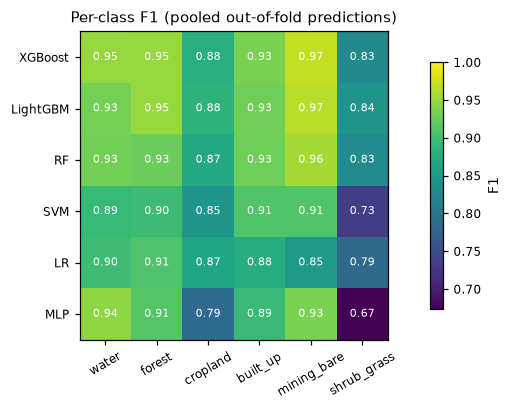

In [11]:
pc = table2[[f"F1 {c}" for c in ru.LC_CLASSES]]
fig, ax = plt.subplots(figsize=(8, 3.8)); im = ax.imshow(pc.values, cmap="viridis", vmin=pc.values.min(), vmax=1)
for i in range(pc.shape[0]):
    for j in range(pc.shape[1]): ax.text(j, i, f"{pc.values[i, j]:.2f}", ha="center", va="center", fontsize=7, color="w")
ax.set_xticks(range(6), ru.LC_CLASSES, rotation=30); ax.set_yticks(range(len(pc)), pc.index); fig.colorbar(im, ax=ax, shrink=0.8, label="F1")
ax.set_title("Per-class F1 (pooled out-of-fold predictions)"); plt.tight_layout(); plt.show()

## **9. How Much Training Data Is Enough? A Spatial Learning Curve**
Sub-sample the training folds (by whole spatial blocks would be stricter; here by points within the training folds) and track spatial-CV performance. A curve that is still rising says that more field data would pay off, which is useful for planning the next field campaign.

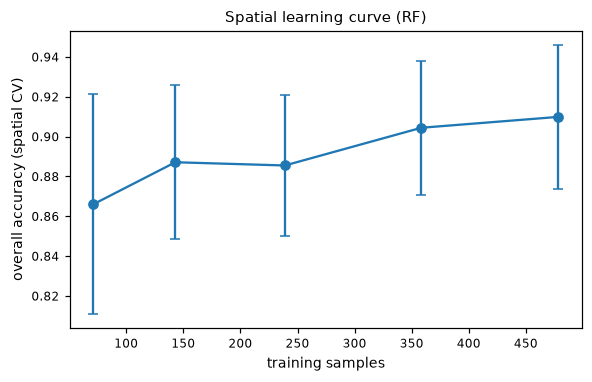

,n_train,OA,sd
fraction,,,
0.15,71.2,0.866,0.055
0.30,143.0,0.887,0.039
0.50,238.9,0.886,0.035
0.75,358.4,0.904,0.034
1.00,478.4,0.910,0.036


In [12]:
fracs = [0.15, 0.3, 0.5, 0.75, 1.0]; lc_rows = []
rng = np.random.default_rng(SEED)
for f in fracs:
    for r, folds in splits[:2]:
        for tr, te in folds:
            sub = rng.choice(tr, int(f * len(tr)), replace=False)
            lc_rows.append({"fraction": f, "n_train": len(sub), "OA": accuracy_score(y[te], rf_fixed().fit(X[sub], y[sub]).predict(X[te]))})
lcurve = pd.DataFrame(lc_rows).groupby("fraction").agg(n_train=("n_train", "mean"), OA=("OA", "mean"), sd=("OA", "std"))
plt.figure(figsize=(6, 3.5)); plt.errorbar(lcurve.n_train, lcurve.OA, yerr=lcurve.sd, fmt="-o", capsize=3)
plt.xlabel("training samples"); plt.ylabel("overall accuracy (spatial CV)"); plt.title("Spatial learning curve (RF)"); plt.show()
lcurve.round(3)

## **10. Writing the Methods and Results**
A paragraph that a reviewer can check against the tables:

In [13]:
second = order[1]
print(f"""Six classifiers (multinomial LR, RF, SVM with RBF kernel, XGBoost, LightGBM and an MLP) were compared using nested
spatial cross-validation: {config['cv']['n_folds']} outer folds of {config['cv']['block_size_m'] / 1000:.0f} km spatial blocks and an inner 3-fold
spatial CV for random hyperparameter search (6 candidates per model, macro F1). {best} achieved the highest macro F1
({table2.loc[best, 'macro F1']:.3f}, 95% CI {table2.loc[best, 'macro F1 CI low']:.3f}-{table2.loc[best, 'macro F1 CI high']:.3f}), followed by {second} ({table2.loc[second, 'macro F1']:.3f}, {table2.loc[second, 'macro F1 CI low']:.3f}-{table2.loc[second, 'macro F1 CI high']:.3f});
the difference between them was {'significant' if mc.iloc[0]['significant at 0.05'] else 'not significant'} (McNemar, Holm-adjusted p = {mc.iloc[0]['p (Holm)']:.3f}).
Adding multi-season, temporal, SAR, texture and terrain features changed the pooled macro F1 from {table3.iloc[0]['macro F1 (pooled)']:.3f} (monsoon Sentinel-2 only)
to {table3.iloc[-1]['macro F1 (pooled)']:.3f} (all features; 3 x 5 repeated spatial CV).""")

Six classifiers (multinomial LR, RF, SVM with RBF kernel, XGBoost, LightGBM and an MLP) were compared using nested
spatial cross-validation: 5 outer folds of 2 km spatial blocks and an inner 3-fold
spatial CV for random hyperparameter search (6 candidates per model, macro F1). XGBoost achieved the highest macro F1
(0.919, 95% CI 0.893-0.938), followed by LightGBM (0.917, 0.893-0.939);
the difference between them was not significant (McNemar, Holm-adjusted p = 1.000).
Adding multi-season, temporal, SAR, texture and terrain features changed the pooled macro F1 from 0.791 (monsoon Sentinel-2 only)
to 0.910 (all features; 3 x 5 repeated spatial CV).


## **Practice Problems**
1. Rank the models by OA instead of macro F1 (Table 2). Does the ranking change? When can the two metrics disagree?
2. Add a k-nearest-neighbour classifier (tune k from 1 to 30 and the weights) to the nested comparison.
3. Reverse the ablation: start from all features and **remove** one group at a time (leave-one-group-out). Which group's removal hurts most?
4. *(Advanced)* Tune LightGBM with **Optuna** (30 trials) using spatial `GroupKFold(5)`, and compare the best score with the `RandomizedSearchCV` result.

In [14]:
# Solution 1
rank = pd.DataFrame({"rank by OA": table2["OA (mean)"].rank(ascending=False), "rank by macro F1": table2["macro F1"].rank(ascending=False)}).astype(int)
print(rank)
print("Same ranking here." if (rank.iloc[:, 0] == rank.iloc[:, 1]).all() else "The rankings differ.",
      "In general they disagree when a model is better on the large or easy classes but worse on a hard minority class.")

          rank by OA  rank by macro F1
XGBoost            1                 1
LightGBM           2                 2
RF                 3                 3
SVM                4                 4
LR                 5                 5
MLP                6                 6
Same ranking here. In general they disagree when a model is better on the large or easy classes but worse on a hard minority class.


In [15]:
# Solution 2
from sklearn.neighbors import KNeighborsClassifier
knn = (make_pipeline(StandardScaler(), KNeighborsClassifier()), {"kneighborsclassifier__n_neighbors": list(range(1, 31)), "kneighborsclassifier__weights": ["uniform", "distance"]})
oof_knn, res_knn = nested_spatial_cv(*knn, X, y, groups)
print(f"kNN nested spatial CV pooled macro F1 {f1_score(y, oof_knn, average='macro'):.3f} (best: {best} {table2.loc[best, 'macro F1']:.3f})")

kNN nested spatial CV pooled macro F1 0.867 (best: XGBoost 0.919)


In [16]:
# Solution 3
all_groups = sorted(set(groups_of.values()))
for g in all_groups:
    cols = [f for f in finfo["all"] if groups_of[f] != g]
    s, f1p = repeated_scores(cols, rf_fixed)
    print(f"without {g:<15}: pooled macro F1 {f1p:.3f} | OA {s.mean():.3f} (diff {s.mean() - full.mean():+.3f}, p = {corrected_ttest(s, full, n_tr, n_te)[1]:.3f})")

without S1             : pooled macro F1 0.892 | OA 0.890 (diff -0.019, p = 0.098)


without S2_index       : pooled macro F1 0.907 | OA 0.906 (diff -0.003, p = 0.519)


without S2_monsoon     : pooled macro F1 0.912 | OA 0.910 (diff +0.001, p = 0.838)


without S2_multiseason : pooled macro F1 0.913 | OA 0.910 (diff +0.001, p = 0.877)


without temporal       : pooled macro F1 0.908 | OA 0.906 (diff -0.003, p = 0.641)


without terrain        : pooled macro F1 0.904 | OA 0.902 (diff -0.007, p = 0.416)


without texture        : pooled macro F1 0.911 | OA 0.910 (diff +0.001, p = 0.804)


In [17]:
# Solution 4
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    m = lgb.LGBMClassifier(n_estimators=300, learning_rate=trial.suggest_float("lr", 0.01, 0.2, log=True), num_leaves=trial.suggest_int("num_leaves", 4, 48),
                           min_child_samples=trial.suggest_int("min_child_samples", 3, 30), colsample_bytree=trial.suggest_float("colsample", 0.3, 1.0),
                           reg_lambda=trial.suggest_float("lambda", 1e-3, 10, log=True), verbose=-1, random_state=SEED, n_jobs=-1)
    return cross_val_score(m, X, y, cv=GroupKFold(5), groups=groups, scoring=mf1_scorer).mean()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30)
print(f"Optuna best spatial-CV macro F1 {study.best_value:.3f} with {study.best_params}")
print(f"Note: this is a tuning score (fold-averaged, optimistically biased). Compare it with the final search's fold-averaged score "
      f"({meta['inner_cv_macro_f1_fold_mean']:.3f}), not with the pooled nested-CV result.")

Optuna best spatial-CV macro F1 0.886 with {'lr': 0.05160033225333421, 'num_leaves': 32, 'min_child_samples': 25, 'colsample': 0.5228499302425755, 'lambda': 0.007250786353093839}
Note: this is a tuning score (fold-averaged, optimistically biased). Compare it with the final search's fold-averaged score (0.887), not with the pooled nested-CV result.


## **Key References**
- Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics*, 7, 91.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895-1923.
- Nadeau, C., & Bengio, Y. (2003). Inference for the generalization error. *Machine Learning*, 52(3), 239-281.
- Foody, G. M. (2004). Thematic map comparison: Evaluating the statistical significance of differences in classification accuracy. *Photogrammetric Engineering & Remote Sensing*, 70(5), 627-633.
- Holm, S. (1979). A simple sequentially rejective multiple test procedure. *Scandinavian Journal of Statistics*, 6(2), 65-70.
- Maxwell, A. E., Warner, T. A., & Fang, F. (2018). Implementation of machine-learning classification in remote sensing: an applied review. *International Journal of Remote Sensing*, 39(9), 2784-2817.
- Schratz, P., Muenchow, J., Iturritxa, E., Richter, J., & Brenning, A. (2019). Hyperparameter tuning and performance assessment of statistical and machine-learning algorithms using spatial data. *Ecological Modelling*, 406, 109-120.